In [26]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

Проверяем стационарность данных и приводим их к стационарному виду

In [27]:
data = pd.read_excel('for_python.xlsx', sheet_name='non stationary')
data.head()

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8
0,2008,0.787712,11.5,-51.53,-2.65,28.12,13.28,10.873634,0.83,6.2
1,2009,0.967433,-3.5,71.31,27.71,24.57,8.80,11.331507,17.66,8.3
2,2010,1.021396,5.2,20.99,-4.38,26.02,8.78,8.031507,31.07,7.3
3,2011,1.089807,2.8,13.54,-3.23,25.51,6.10,8.122603,20.95,6.5
4,2012,1.125858,8.4,3.91,5.71,23.97,6.57,8.074454,12.23,5.5


In [28]:
non_stationary = [] # пройдемся по всем переменным (кроме поля с годами)
for col_name in data.columns[1:]:
    indicator = data[col_name] # Series со значениями переменной с 2008 по 2025
    result = adfuller(indicator)
    print(f'Переменная {col_name}:')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] < 0.05:
        print('Ряд стационарен (отвергаем H0)')
    else:   
        print('Ряд нестационарен (не отвергаем H0)')
        non_stationary.append(col_name)
    print()

Переменная Y:
ADF Statistic: 6.57388446930857
p-value: 1.0
Critical Values: {'1%': np.float64(-4.331573), '5%': np.float64(-3.23295), '10%': np.float64(-2.7487)}
Ряд нестационарен (не отвергаем H0)

Переменная X1:
ADF Statistic: -4.105095120844684
p-value: 0.0009499123139825534
Critical Values: {'1%': np.float64(-3.889265672705068), '5%': np.float64(-3.0543579727254224), '10%': np.float64(-2.66698384083045)}
Ряд стационарен (отвергаем H0)

Переменная X2:
ADF Statistic: -2.3624648969356072
p-value: 0.15261178993549906
Critical Values: {'1%': np.float64(-4.068853732362312), '5%': np.float64(-3.1271488757396453), '10%': np.float64(-2.7017297633136095)}
Ряд нестационарен (не отвергаем H0)

Переменная X3:
ADF Statistic: -2.0757714784842274
p-value: 0.2543679357580919
Critical Values: {'1%': np.float64(-4.331573), '5%': np.float64(-3.23295), '10%': np.float64(-2.7487)}
Ряд нестационарен (не отвергаем H0)

Переменная X4:
ADF Statistic: -0.8783230006102719
p-value: 0.795027128419532
Critical V

In [29]:
non_stationary

['Y', 'X2', 'X3', 'X4', 'X8']

Учтем, что данные переменные нестационарны и преобразуем их в темпы прироста

In [30]:
data = pd.read_excel('for_python.xlsx', sheet_name='2nd try')
data.head()

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8
0,2008,33.556905,11.5,-51.529036,-2.651927,4.148148,13.28,10.873634,0.83,0.2
1,2009,22.815554,-3.5,71.312376,27.711434,-12.624467,8.80,11.331507,17.66,2.1
2,2010,5.577892,5.2,20.993199,-4.376708,5.901506,8.78,8.031507,31.07,-1.0
3,2011,6.697763,2.8,13.543324,-3.231815,-1.960031,6.10,8.122603,20.95,-0.8
4,2012,3.308088,8.4,3.913693,5.713060,-6.036848,6.57,8.074454,12.23,-1.0


In [31]:
non_stationary = [] # пройдемся по всем переменным (кроме поля с годами)
for col_name in data.columns[1:]:
    indicator = data[col_name] # Series со значениями переменной с 2008 по 2025
    result = adfuller(indicator)
    print(f'Переменная {col_name}:')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] < 0.05:
        print('Ряд стационарен (отвергаем H0)')
    else:   
        print('Ряд нестационарен (не отвергаем H0)')
        non_stationary.append(col_name)
    print()

Переменная Y:
ADF Statistic: 1.463588092406292
p-value: 0.9973847059280863
Critical Values: {'1%': np.float64(-4.331573), '5%': np.float64(-3.23295), '10%': np.float64(-2.7487)}
Ряд нестационарен (не отвергаем H0)

Переменная X1:
ADF Statistic: -4.105095120844684
p-value: 0.0009499123139825534
Critical Values: {'1%': np.float64(-3.889265672705068), '5%': np.float64(-3.0543579727254224), '10%': np.float64(-2.66698384083045)}
Ряд стационарен (отвергаем H0)

Переменная X2:
ADF Statistic: -2.362648928101013
p-value: 0.1525570911884374
Critical Values: {'1%': np.float64(-4.068853732362312), '5%': np.float64(-3.1271488757396453), '10%': np.float64(-2.7017297633136095)}
Ряд нестационарен (не отвергаем H0)

Переменная X3:
ADF Statistic: -2.077210034249533
p-value: 0.25377674137863604
Critical Values: {'1%': np.float64(-4.331573), '5%': np.float64(-3.23295), '10%': np.float64(-2.7487)}
Ряд нестационарен (не отвергаем H0)

Переменная X4:
ADF Statistic: -3.932707470697609
p-value: 0.0018068983095

In [32]:
non_stationary

['Y', 'X2', 'X3']

X2 и X3 Колеблются возле 0, высокий p-value связан с выбросами (резкими скачками в стоимости доллара/нефти). Y попробуем прологарифмировать. Если не получится, то придется признать наличие структурного сдвига и работать с тем, что есть

In [33]:
new_y = pd.read_excel('for_python.xlsx', sheet_name='Y to log')
new_y.head()

,Year,Y
0,2007,0.589795
1,2008,0.787712
2,2009,0.967433
3,2010,1.021396
4,2011,1.089807


In [34]:
# используем логарифмические разности вместо цепных темпов прироста
log_y = np.diff(np.log(new_y['Y']))
result = adfuller(log_y)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])
if result[1] < 0.05:
    print('Ряд стационарен (отвергаем H0)')
else:   
    print('Ряд нестационарен (не отвергаем H0)')
    non_stationary.append(col_name)

ADF Statistic: -2.9561688590514086
p-value: 0.039195402490448054
Critical Values: {'1%': np.float64(-4.331573), '5%': np.float64(-3.23295), '10%': np.float64(-2.7487)}
Ряд стационарен (отвергаем H0)


Мы справились со стационарностью

In [35]:
data['Y'] = log_y
data.head()
#data.to_excel('result.xlsx') # Оставим возможность сохранить итоговый датасет для работы в экселе

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8
0,2008,0.289357,11.5,-51.529036,-2.651927,4.148148,13.28,10.873634,0.83,0.2
1,2009,0.205513,-3.5,71.312376,27.711434,-12.624467,8.80,11.331507,17.66,2.1
2,2010,0.054279,5.2,20.993199,-4.376708,5.901506,8.78,8.031507,31.07,-1.0
3,2011,0.064830,2.8,13.543324,-3.231815,-1.960031,6.10,8.122603,20.95,-0.8
4,2012,0.032545,8.4,3.913693,5.713060,-6.036848,6.57,8.074454,12.23,-1.0


Мы сформировали готовый датасет, в котором все значения стационарны. Можем переходить к анализу корреляции и тесту грейнджера

Text(0.5, 1.0, 'Матрица корреляций между факторами инвестиционной активности')

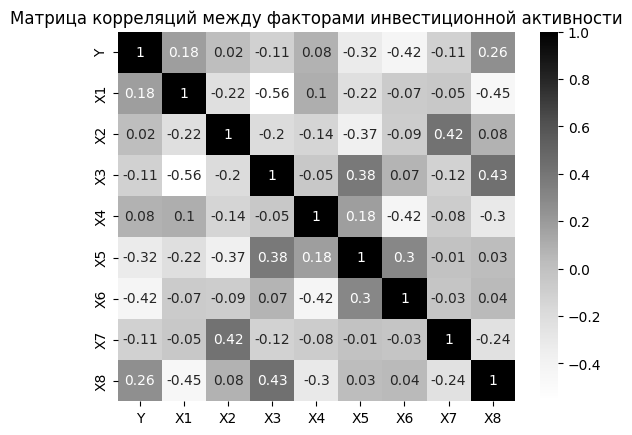

In [36]:
sns.heatmap(data.iloc[:, 1:].corr().round(2), annot=True, cmap='Greys')
plt.title('Матрица корреляций между факторами инвестиционной активности')

In [37]:
warnings.filterwarnings('ignore')
for col_name in [f"X{i}" for i in range(1, 9)]:
    print('='*20, f'Анализ {col_name}', '='*20)
    res = grangercausalitytests(data[['Y', col_name]], maxlag=2, verbose=False)
    for lag in range(1, 3):
        p_f = res[lag][0]['ssr_ftest'][1]
        p_chi2 = res[lag][0]['ssr_chi2test'][1]
        print(f"При лаге = {lag}: F p-value = {round(p_f, 4)}, Хи2 p-value = {round(p_chi2, 4)}")


==================== Анализ X1 ====================
При лаге = 1: F p-value = 0.604, Хи2 p-value = 0.5587
При лаге = 2: F p-value = 0.6471, Хи2 p-value = 0.5175
==================== Анализ X2 ====================
При лаге = 1: F p-value = 0.8831, Хи2 p-value = 0.8689
При лаге = 2: F p-value = 0.6388, Хи2 p-value = 0.507
==================== Анализ X3 ====================
При лаге = 1: F p-value = 0.474, Хи2 p-value = 0.4174
При лаге = 2: F p-value = 0.4827, Хи2 p-value = 0.3221
==================== Анализ X4 ====================
При лаге = 1: F p-value = 0.4529, Хи2 p-value = 0.3949
При лаге = 2: F p-value = 0.0755, Хи2 p-value = 0.0082
==================== Анализ X5 ====================
При лаге = 1: F p-value = 0.0289, Хи2 p-value = 0.0073
При лаге = 2: F p-value = 0.3967, Хи2 p-value = 0.2312
==================== Анализ X6 ====================
При лаге = 1: F p-value = 0.8877, Хи2 p-value = 0.8741
При лаге = 2: F p-value = 0.9636, Хи2 p-value = 0.9473
==================== Анализ X7 

Напишем такую функцию, которая будет считать точность прогноза на три года вперед, вычисляя ее RMSE. 

In [59]:
def expanding_validation(X, y, min_train=10, use_scaler=True):
    alphas = np.logspace(-3, 4, 100) # все параметры Ridge которые будем перебирать
    results_rmse = []
    results_mape = []
    # Пройдемся по всем годам от минимального до итогового
    for test_idx in range(min_train, len(X)):
            # Обучающая выборка: все строки до test_idx (не включая test_idx)
            X_train = X.iloc[:test_idx]
            y_train = y.iloc[:test_idx]
            # Тестовая выборка: test_idx
            end_index = min(len(X), test_idx + 3)
            X_test = X.iloc[test_idx:end_index]
            y_test = y.iloc[test_idx:end_index]
            rmse_for_alpha = []
            mape_for_alpha = []
            for alpha in alphas:
                if use_scaler:
                    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
                else:
                    model = Ridge(alpha=alpha)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mape = mean_absolute_percentage_error(y_test, y_pred)
                rmse_for_alpha.append(rmse)
                mape_for_alpha.append(mape)
                
            results_rmse.append(rmse_for_alpha)
            results_mape.append(mape_for_alpha)
    # Преобразуем в массив: строки — тестовые годы, столбцы — alpha
    results_rmse = np.array(results_rmse)  # shape = (n_test_years, n_alphas)
    results_mape = np.array(results_mape)  # shape = (n_test_years, n_alphas)
    # Усредняем RMSE по всем тестовым годам для каждого alpha
    mean_rmse = results_rmse.mean(axis=0)
    mean_mape = results_mape.mean(axis=0)
    # Находим alpha с минимальным средним RMSE
    best_alpha = alphas[np.argmin(mean_rmse)]

    print(f'Оптимальный alpha: {best_alpha:.4f}')
    print(f'Средний RMSE при этом alpha: {mean_rmse.min():.4f}')
    print(f'Средний MAPE при этом alpha: {mean_mape[np.argmin(mean_rmse)]:.4f}')
    return best_alpha



In [60]:
# 1 модель: со всеми данными без учета лагов
X = data.iloc[:,2:]
y = data['Y']
print('Без StandardScaler')
expanding_validation(X, y, use_scaler=False)
print('\nС применением StandardScaler')
expanding_validation(X, y)

Без StandardScaler
Оптимальный alpha: 278.2559
Средний RMSE при этом alpha: 0.2833
Средний MAPE при этом alpha: 0.4765

С применением StandardScaler
Оптимальный alpha: 75.6463
Средний RMSE при этом alpha: 0.2509
Средний MAPE при этом alpha: 0.4168


np.float64(75.64633275546291)

In [61]:
# 2 модель: Строим на основе значимых показателей с лагами по тесту Грейнджера
df = pd.DataFrame() # строим датафрейм
df['Year'] = data['Year']
df['Y'] = data['Y']
df['X4'] = data['X4'].shift(2)
df['X5'] = data['X5'].shift(1)
df['X8'] = data['X8'].shift(2)
df.dropna(axis=0, inplace=True)
df.head()

,Year,Y,X4,X5,X8
2,2010,0.054279,4.148148,8.80,0.2
3,2011,0.064830,-12.624467,8.78,2.1
4,2012,0.032545,5.901506,6.10,-1.0
5,2013,0.091488,-1.960031,6.57,-0.8
6,2014,0.065822,-6.036848,6.47,-1.0


In [62]:
X = df[['X4', 'X5', 'X8']]
y = df['Y']
print('Без StandardScaler')
expanding_validation(X, y, use_scaler=False)
print('\nС применением StandardScaler')
expanding_validation(X, y)

Без StandardScaler
Оптимальный alpha: 739.0722
Средний RMSE при этом alpha: 0.1631
Средний MAPE при этом alpha: 0.3867

С применением StandardScaler
Оптимальный alpha: 20.5651
Средний RMSE при этом alpha: 0.1447
Средний MAPE при этом alpha: 0.3159


np.float64(20.565123083486515)

Можем заметить, что модель с лагами показала себя лучше. Попробуем построить модель по всем данным

In [63]:
# 3 модель: Все данные + значимые данные по Грейнджеру с лагом
df = data.copy()
df['X4'] = df['X4'].shift(2)
df['X5'] = df['X5'].shift(1)
df['X8'] = df['X8'].shift(2)
df.dropna(axis=0, inplace=True)
df.head()

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8
2,2010,0.054279,5.2,20.993199,-4.376708,4.148148,8.80,8.031507,31.07,0.2
3,2011,0.064830,2.8,13.543324,-3.231815,-12.624467,8.78,8.122603,20.95,2.1
4,2012,0.032545,8.4,3.913693,5.713060,5.901506,6.10,8.074454,12.23,-1.0
5,2013,0.091488,4.8,-0.593258,2.677894,-1.960031,6.57,7.632485,14.69,-0.8
6,2014,0.065822,1.2,-47.969979,20.986958,-6.036848,6.47,7.967611,1.48,-1.0


In [64]:
X = df.iloc[:, 2:]
y = df['Y']
print('Без StandardScaler')
expanding_validation(X, y, use_scaler=False)
print('\nС применением StandardScaler')
expanding_validation(X, y)

Без StandardScaler
Оптимальный alpha: 869.7490
Средний RMSE при этом alpha: 0.1612
Средний MAPE при этом alpha: 0.3363

С применением StandardScaler
Оптимальный alpha: 89.0215
Средний RMSE при этом alpha: 0.1304
Средний MAPE при этом alpha: 0.2540


np.float64(89.02150854450375)

По шкале Льюиса MAPE 25.4% – приемлемый прогноз. Однако попробуем улучшить нашу модель с помощью ElasticNet, чтобы улучшить результат

In [65]:
# Напишем новую валидацию для ElasticNet
def expanding_validation_elastic(X, y, min_train=10, l1_ratios=[0.1,0.5,0.7,0.9,0.95,1.0], use_scaler=True):
    alphas = np.logspace(-3, 4, 50)
    results_rmse = {l1: [] for l1 in l1_ratios}
    results_mape = {l1: [] for l1 in l1_ratios}
    for test_idx in range(min_train, len(X)):
        # Обучающая выборка: все строки до test_idx (не включая test_idx)
        X_train = X.iloc[:test_idx]
        y_train = y.iloc[:test_idx]
        # Тестовая выборка: test_idx
        end_index = min(len(X), test_idx + 3)
        X_test = X.iloc[test_idx:end_index]
        y_test = y.iloc[test_idx:end_index]
        for l1 in l1_ratios:
            rmse_errors = []
            mape_errors = []
            for alpha in alphas:
                if use_scaler:
                    model = make_pipeline(StandardScaler(), ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000))
                else:
                    model = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mape = mean_absolute_percentage_error(y_test, y_pred)
                rmse_errors.append(rmse)
                mape_errors.append(mape)
            results_rmse[l1].append(rmse_errors)
            results_mape[l1].append(mape_errors)
    # усредняем по тестовым окнам для каждого l1 и alpha
    best_rmse = np.inf
    best_mape = np.inf
    for l1 in l1_ratios:
        # Преобразуем в массив: строки — тестовые годы, столбцы — alpha
        arr_rmse = np.array(results_rmse[l1]) # shape = (n_test_years, n_alphas)
        # Среднее значение rmse по каждому alpha
        mean_rmse = arr_rmse.mean(axis=0)
        min_rmse = mean_rmse.min()
        if min_rmse < best_rmse:
            best_rmse = min_rmse
            best_alpha = alphas[np.argmin(mean_rmse)]
            best_l1 = l1
            # Также выцепляем соответствующий mape при лучшем с точки зрения rmse alpha 
            best_mape = np.array(results_mape[l1]).mean(axis=0)[np.argmin(mean_rmse)]
    print(f'Optimal ElasticNet: alpha={best_alpha:.4f}, l1_ratio={best_l1}, RMSE={best_rmse:.4f}, MAPE={best_mape:.4f}')
    return (best_alpha, best_l1)

In [66]:
X = df.iloc[:, 2:]
y = df['Y']
print('Без StandardScaler')
expanding_validation_elastic(X, y, use_scaler=False)
print('\nС применением StandardScaler')
expanding_validation_elastic(X, y)

Без StandardScaler
Optimal ElasticNet: alpha=0.5179, l1_ratio=0.7, RMSE=0.1611, MAPE=0.3571

С применением StandardScaler
Optimal ElasticNet: alpha=1.0000, l1_ratio=0.1, RMSE=0.1498, MAPE=0.4001


(np.float64(1.0), 0.1)

Elastic Net Не улучшил ситуацию: по нему RMSE вырос. Это говорит о том, что в модели нет ненужных переменных и их нельзя обнулять: какой-то эффект они имеют в любом случае и их тоже важно учесть. По MAPE ситуация еще хуже, через ElasticNet относительная ошибка еще выше Наконец, попробуем применить авторегрессию с зависимой переменной: если она не улучшит третью модель, то оставляем ее

In [69]:
def expanding_validation_recursive(X, y, min_train=10, use_scaler=True):
    alphas = np.logspace(-3, 4, 100) # все параметры Ridge которые будем перебирать
    results_rmse = []
    results_mape = []
    # Пройдемся по всем годам от минимального до итогового
    for test_idx in range(min_train, len(X)):
            # Обучающая выборка: все строки до test_idx (не включая test_idx)
            X_train = X.iloc[:test_idx]
            y_train = y.iloc[:test_idx]
            # Тестовая выборка: test_idx + 2 значения вперед
            end_index = min(len(X), test_idx + 3)
            X_test = X.iloc[test_idx:end_index]
            y_test = y.iloc[test_idx:end_index]
            rmse_for_alpha = []
            mape_for_alpha = []
            for alpha in alphas:
                if use_scaler:
                    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
                else:
                    model = Ridge(alpha=alpha)
                model.fit(X_train, y_train)
                y_lag = y_train.iloc[-1]
                y_pred = []
                for i in range(len(X_test)):
                    row = X_test.iloc[i, :]
                    row['Y_lag'] = y_lag
                    inner_df = pd.DataFrame(row.to_numpy().reshape(1, -1),
                                        columns=row.index)
                    prediction = model.predict(inner_df)[0]
                    y_lag = prediction
                    y_pred.append(prediction)
                y_pred = np.array(y_pred)
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mape = mean_absolute_percentage_error(y_test, y_pred)
                rmse_for_alpha.append(rmse)
                mape_for_alpha.append(mape)
                
            results_rmse.append(rmse_for_alpha)
            results_mape.append(mape_for_alpha)
    # Преобразуем в массив: строки — тестовые годы, столбцы — alpha
    results_rmse = np.array(results_rmse)  # shape = (n_test_years, n_alphas)
    results_mape = np.array(results_mape)  # shape = (n_test_years, n_alphas)
    # Усредняем RMSE по всем тестовым годам для каждого alpha
    mean_rmse = results_rmse.mean(axis=0)
    mean_mape = results_mape.mean(axis=0)
    # Находим alpha с минимальным средним RMSE
    best_alpha = alphas[np.argmin(mean_rmse)]

    print(f'Оптимальный alpha: {best_alpha:.4f}')
    print(f'Средний RMSE при этом alpha: {mean_rmse.min():.4f}')
    print(f'Средний MAPE при этом alpha: {mean_mape[np.argmin(mean_rmse)]:.4f}')
    return best_alpha

In [71]:
df = data.copy()
df['X4'] = df['X4'].shift(2)
df['X5'] = df['X5'].shift(1)
df['X8'] = df['X8'].shift(2)
df['Y_lag'] = df['Y'].shift(1)
df.dropna(axis=0, inplace=True)
df.head()

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8,Y_lag
2,2010,0.054279,5.2,20.993199,-4.376708,4.148148,8.80,8.031507,31.07,0.2,0.205513
3,2011,0.064830,2.8,13.543324,-3.231815,-12.624467,8.78,8.122603,20.95,2.1,0.054279
4,2012,0.032545,8.4,3.913693,5.713060,5.901506,6.10,8.074454,12.23,-1.0,0.064830
5,2013,0.091488,4.8,-0.593258,2.677894,-1.960031,6.57,7.632485,14.69,-0.8,0.032545
6,2014,0.065822,1.2,-47.969979,20.986958,-6.036848,6.47,7.967611,1.48,-1.0,0.091488


In [72]:
# Посчитаем для заданного датасета с автокорреляцией Ridge
X = df.iloc[:, 2:]
y = df['Y']
print('Без StandardScaler')
expanding_validation_recursive(X, y, use_scaler=False)
print('\nС применением StandardScaler')
alpha = expanding_validation_recursive(X, y)
df.head()

Без StandardScaler
Оптимальный alpha: 869.7490
Средний RMSE при этом alpha: 0.1611
Средний MAPE при этом alpha: 0.3362

С применением StandardScaler
Оптимальный alpha: 64.2807
Средний RMSE при этом alpha: 0.1043
Средний MAPE при этом alpha: 0.2104


,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8,Y_lag
2,2010,0.054279,5.2,20.993199,-4.376708,4.148148,8.80,8.031507,31.07,0.2,0.205513
3,2011,0.064830,2.8,13.543324,-3.231815,-12.624467,8.78,8.122603,20.95,2.1,0.054279
4,2012,0.032545,8.4,3.913693,5.713060,5.901506,6.10,8.074454,12.23,-1.0,0.064830
5,2013,0.091488,4.8,-0.593258,2.677894,-1.960031,6.57,7.632485,14.69,-0.8,0.032545
6,2014,0.065822,1.2,-47.969979,20.986958,-6.036848,6.47,7.967611,1.48,-1.0,0.091488


В итоге, лучший результат показала Ridge модель со всеми переменными, часть из которых, в том числе сама целевая переменная, содержится в предикторах с лагами. Удалось достичь RMSE = 10,43% и MAPE = 21,04%

In [73]:

df.head()
# df.to_excel('result.xlsx', sheet_name='for_prediction') # Сохраняем для формирования датасета для прогноза в экселе

,Year,Y,X1,X2,X3,X4,X5,X6,X7,X8,Y_lag
2,2010,0.054279,5.2,20.993199,-4.376708,4.148148,8.80,8.031507,31.07,0.2,0.205513
3,2011,0.064830,2.8,13.543324,-3.231815,-12.624467,8.78,8.122603,20.95,2.1,0.054279
4,2012,0.032545,8.4,3.913693,5.713060,5.901506,6.10,8.074454,12.23,-1.0,0.064830
5,2013,0.091488,4.8,-0.593258,2.677894,-1.960031,6.57,7.632485,14.69,-0.8,0.032545
6,2014,0.065822,1.2,-47.969979,20.986958,-6.036848,6.47,7.967611,1.48,-1.0,0.091488


In [74]:
def create_model(alpha, X, y):
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    model.fit(X, y)
    return model

def forecast(model):

    scenarios = [
        'Базовый',
        'Дезинфляционный',
        'Проинфляционный',
        'Кризисный'
    ]
    prediction = {scenario: [] for scenario in scenarios}
    for scenario in scenarios:
        y_lag = df['Y'].iloc[-1]
        predictors = pd.read_excel('for_prediction.xlsx', sheet_name=scenario).iloc[:, 1:]
        for i in range(len(predictors)):
            row = predictors.iloc[i, :]
            row['Y_lag'] = y_lag
            inner_df = pd.DataFrame(row.to_numpy().reshape(1, -1),
                                    columns=row.index)
            y_prediction = model.predict(inner_df)[0]
            y_lag = y_prediction
            prediction[scenario].append(y_prediction)
            
    return pd.DataFrame(prediction, index=[2026, 2027, 2028])



model = create_model(alpha, X, y)
result = forecast(model)
result



,Базовый,Дезинфляционный,Проинфляционный,Кризисный
2026,0.226225,0.232785,0.210377,0.207533
2027,0.258960,0.265632,0.233620,0.148783
2028,0.306201,0.307173,0.281723,0.218725


Таким образом, мы получили прогноз по темпу прироста вовлеченности трудовых ресурсов в инвестиционную деятельность. Переведем их в долю

In [75]:
scenarios = [
        'Базовый',
        'Дезинфляционный',
        'Проинфляционный',
        'Кризисный'
    ]
finale = {scenario: [] for scenario in scenarios}
initial_involvement = 54.57
for growths, scenario in zip(result.to_numpy().T, result.columns):
    x = initial_involvement
    for growth in growths:
        x *= 1 + growth
        finale[scenario].append(x)
finale = pd.DataFrame(finale)
finale

,Базовый,Дезинфляционный,Проинфляционный,Кризисный
0,66.915075,67.273057,66.050297,65.895070
1,84.243404,85.142929,81.480971,75.699154
2,110.038778,111.296502,104.436071,92.256481


В результате мы можем увидеть, что все сценарии очень позитивно отражают вовлеченность трудовых ресурсов в инвестиционную деятельность: к 2028 году регрессия предсказала невозможное значение: 110%, 111%. Даже в кризисном сценарии % нереалистичен. 

In [ ]:
# Причина таких завышенных результатов видится в следующем:
# В 2017 году произошел структурный сдвиг, с того момента целевая переменная начала демонстрировать усиленный рост, пик которого пришелся на 2020 год.
# Такая серьезная волатильность плохо ложится в линейный тренд. Модель попыталась учесть этот скачок, в результате чего прогноз стал завышен
# Возможно также, что взгляд на среднесрочную перспективу у ЦБ и Минэкономразвития по нашим предикторам очень оптимистичен, что могло завысить оценку
# Несмотря на завышенность оценки, общий тренд по сценариям логичен – самый бурный темп развития наблюдается у дезинфляционного периода, а самый слабый – кризисный
# Далее оптимально сжать результаты, чтобы, например, лучший результат на 2028 год был равен ~85%, сохранив тенденции по сценариям

In [ ]:
# finale.to_excel('result.xlsx', 'Прогноз')